# Student Performance Prediction (Improved ML Pipeline)
This notebook includes preprocessing, outlier removal, feature engineering, model training, and visualizations.

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

In [130]:
pip install imblearn


Note: you may need to restart the kernel to use updated packages.


In [94]:
df = pd.read_csv('student_academic_performance.csv')

In [96]:
df.head()

,Student ID,Gender,Race/Ethnicity,Parental Education,Lunch Type,Test Preparation,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score,School Type,Internet Access
0,1,female,group B,some college,standard,False,12.4,5.4,62.0,76.0,65.0,public,True
1,2,male,group D,high school,standard,False,18.3,5.1,74.0,73.0,76.0,public,NaN
2,3,male,group B,bachelor degree,free/reduced,True,11.8,7.8,71.0,83.0,91.0,public,False
3,4,male,group E,high school,standard,False,NaN,7.3,83.0,73.0,52.0,public,True
4,5,female,group C,bachelor degree,standard,True,12.9,6.3,41.0,NaN,81.0,public,True


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student ID            7000 non-null   int64  
 1   Gender                7000 non-null   object 
 2   Race/Ethnicity        7000 non-null   object 
 3   Parental Education    6300 non-null   object 
 4   Lunch Type            6790 non-null   object 
 5   Test Preparation      7000 non-null   bool   
 6   Study Time per Week   6370 non-null   float64
 7   Daily Sleep Duration  6440 non-null   float64
 8   Math Score            7000 non-null   float64
 9   Reading Score         6510 non-null   float64
 10  Writing Score         6650 non-null   float64
 11  School Type           7000 non-null   object 
 12  Internet Access       6720 non-null   object 
dtypes: bool(1), float64(5), int64(1), object(6)
memory usage: 663.2+ KB


In [100]:
df.shape

(7000, 13)

In [102]:
df.describe()

,Student ID,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score
count,7000.000000,6370.000000,6440.000000,7000.000000,6510.000000,6650.000000
mean,3500.500000,9.662653,7.193587,69.476571,71.134101,70.460451
std,2020.870275,4.681971,1.316991,14.782909,13.818268,13.699283
min,1.000000,0.000000,3.000000,3.000000,21.000000,14.000000
25%,1750.750000,6.400000,6.300000,59.000000,62.000000,61.000000
50%,3500.500000,9.600000,7.200000,70.000000,71.000000,71.000000
75%,5250.250000,12.800000,8.100000,80.000000,81.000000,80.000000
max,7000.000000,26.100000,11.000000,100.000000,100.000000,100.000000


In [104]:
df.columns

Index(['Student ID', 'Gender', 'Race/Ethnicity', 'Parental Education',
       'Lunch Type', 'Test Preparation', 'Study Time per Week',
       'Daily Sleep Duration', 'Math Score', 'Reading Score', 'Writing Score',
       'School Type', 'Internet Access'],
      dtype='object')

In [106]:
df = df.drop_duplicates()
df = df.drop(columns=['Student ID'])

In [108]:
cat_cols = df.select_dtypes(include='object').columns


In [110]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [112]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Keep rows that are NOT outliers
df = df[~((numeric_df < (Q1 - 1.5 * IQR)) | 
          (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)].copy()

In [114]:
# Combine scores → STRONG FEATURE
df['avg_score'] = (df['Math Score'] + df['Reading Score'] + df['Writing Score']) / 3

# Drop individual scores (optional but powerful)
df = df.drop(['Math Score','Reading Score','Writing Score'], axis=1)

In [120]:
y = pd.cut(df['avg_score'], bins=[0,50,75,100], labels=[0,1,2], include_lowest=True)

# Remove NaNs if any remain
mask = y.notna()
X = df.loc[mask].drop('avg_score', axis=1)
y = y[mask]

In [132]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [134]:
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

In [136]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [138]:
model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [140]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6869479882237488
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.70      0.96      0.81       719
           2       0.29      0.04      0.07       294

    accuracy                           0.69      1019
   macro avg       0.33      0.33      0.29      1019
weighted avg       0.58      0.69      0.59      1019



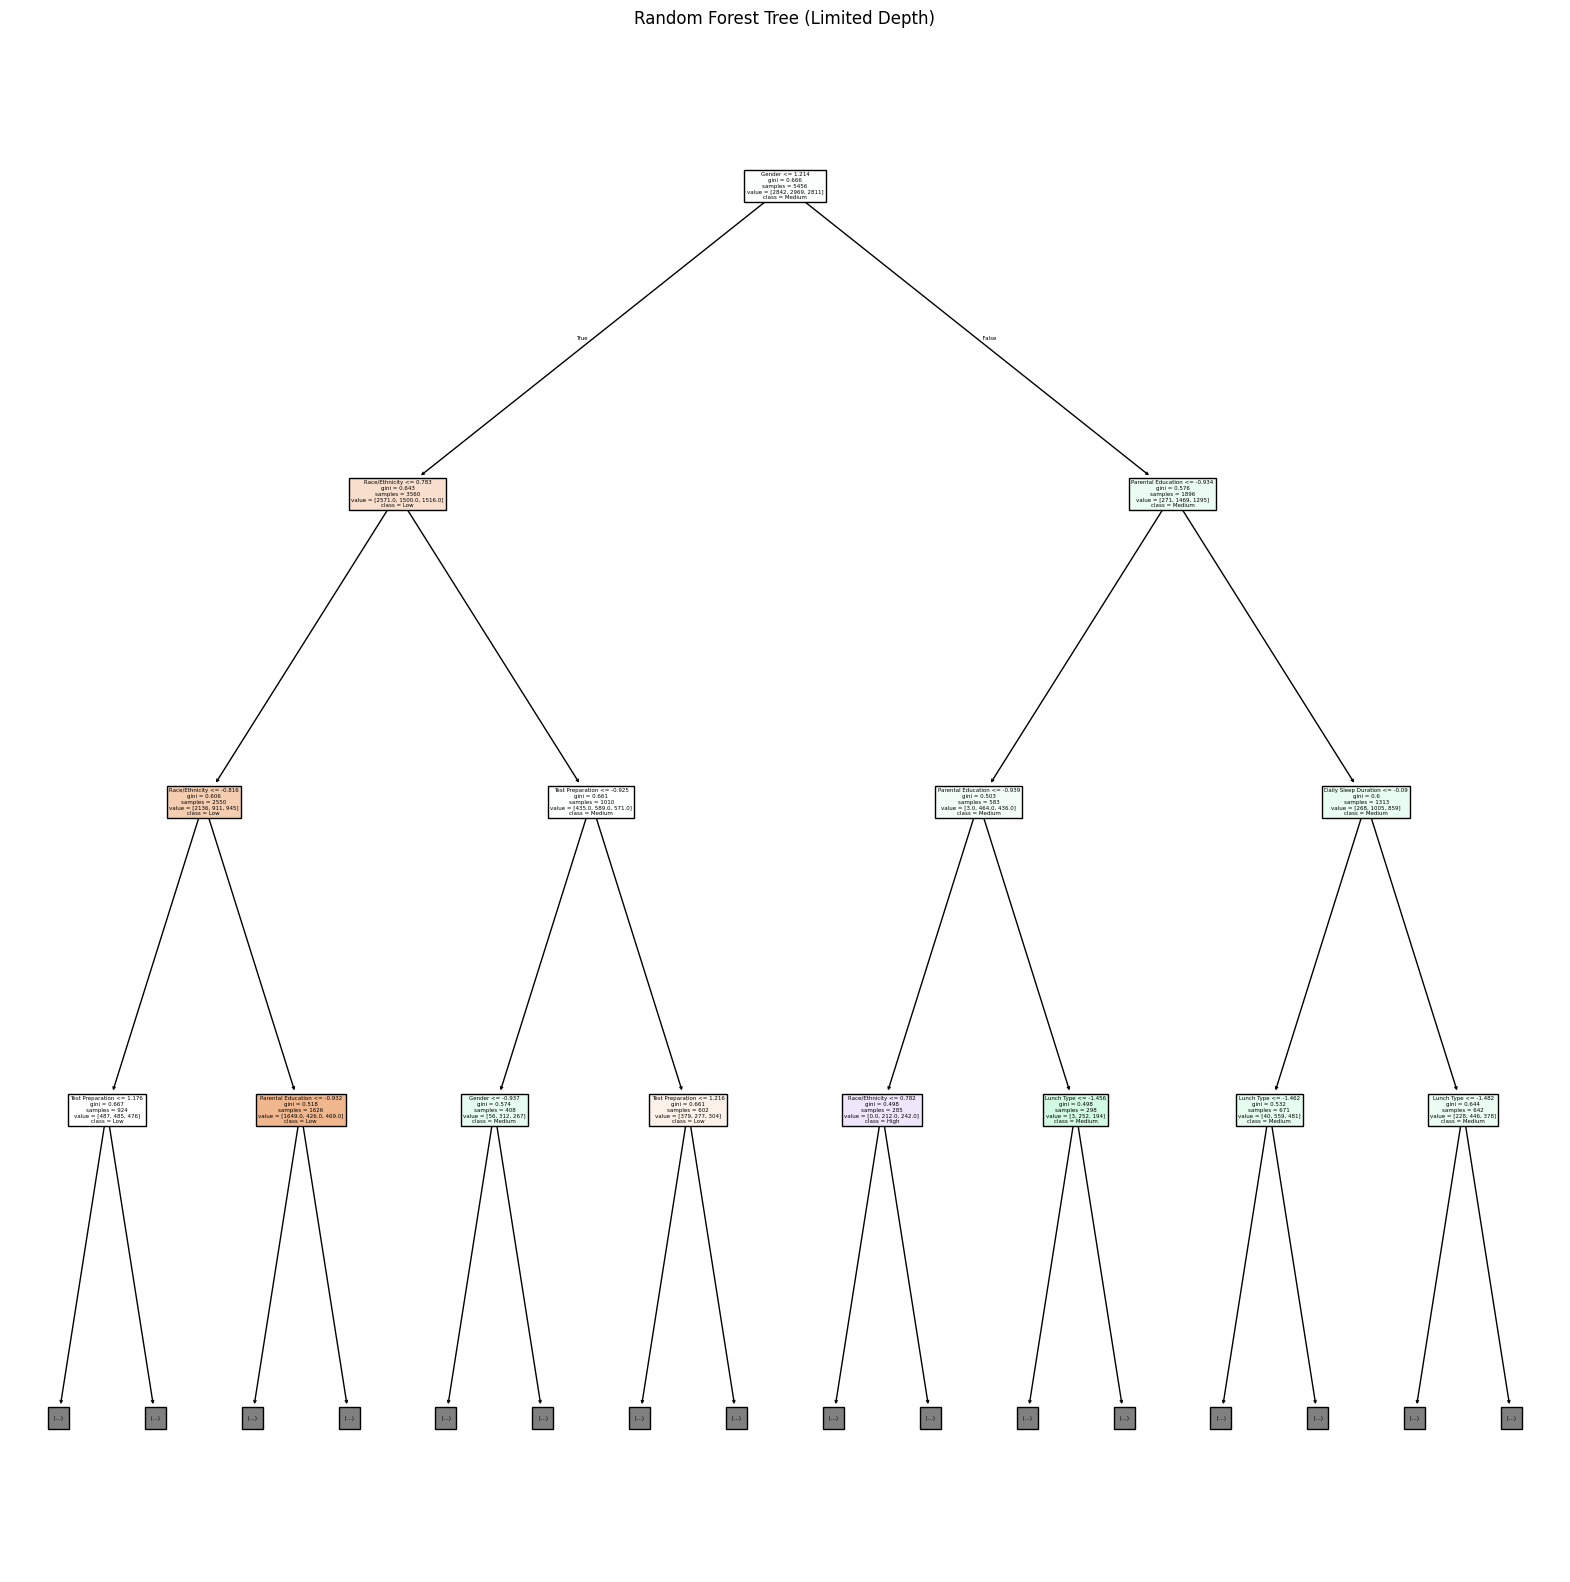

In [150]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,20))

plot_tree(
    model.estimators_[0],
    feature_names=X.columns,
    class_names=['Low','Medium','High'],
    filled=True,
    max_depth=3  
)

plt.title("Random Forest Tree (Limited Depth)")
plt.show()

In [152]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6869479882237488


In [154]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.70      0.96      0.81       719
           2       0.29      0.04      0.07       294

    accuracy                           0.69      1019
   macro avg       0.33      0.33      0.29      1019
weighted avg       0.58      0.69      0.59      1019



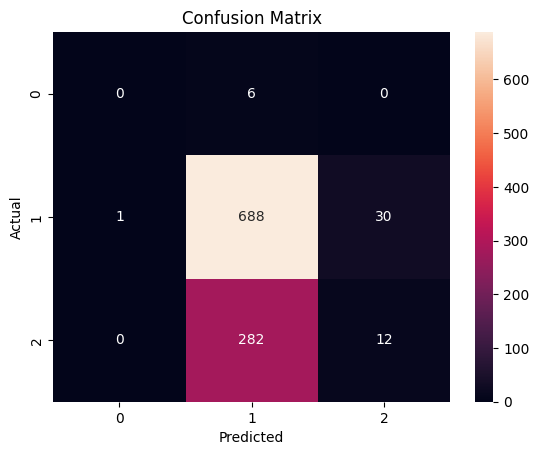

In [156]:

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [158]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.7037906495639817


In [160]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.8981674785432614
Test Accuracy: 0.6869479882237488
